<a href="https://colab.research.google.com/github/MarcelaDomici/Analise-IMDb-Movies-Dataset/blob/main/ProjetoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exploração Inicial

In [21]:
# Importando bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast


In [3]:
# Carregando o dataset
df = pd.read_csv('/content/tmdb_5000_movies.csv')

display(df.head())
print(df.info())
print(df.describe())

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [4]:
df.isnull().sum()

,0
budget,0
genres,0
homepage,3091
id,0
keywords,0
original_language,0
original_title,0
overview,3
popularity,0
production_companies,0


In [5]:
df.select_dtypes(include=['object']).columns  # categóricas
df.select_dtypes(include=['number']).columns  # numéricas

Index(['budget', 'id', 'popularity', 'revenue', 'runtime', 'vote_average',
       'vote_count'],
      dtype='object')

In [6]:
# Verificar duplicados
print(f"Duplicados: {df.duplicated().sum()}")

# Remover duplicados
df = df.drop_duplicates()


Duplicados: 0


In [9]:
# Verificar novamente valores ausentes
df.isnull().sum()

num_cols = ['budget', 'revenue', 'vote_average', 'popularity']
cat_cols = df.select_dtypes(include=['object']).columns

# Para colunas numéricas
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Para colunas categóricas
for col in cat_cols:
    df[col] = df[col].fillna('Desconhecido')


In [10]:
# Colunas categóricas em letras minúsculas
for col in cat_cols:
    df[col] = df[col].str.lower()

In [11]:
# Ajustar tipo de data
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

# Converter colunas numéricas
df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')
df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')



Estatística Descritiva

In [12]:
# Selecionando as colunas numéricas de interesse
num_cols = ['budget', 'revenue', 'vote_average', 'popularity']

# Calculando estatísticas individuais
estatisticas = pd.DataFrame({
    'Média': df[num_cols].mean(),
    'Mediana': df[num_cols].median(),
    'Desvio Padrão': df[num_cols].std(),
    'Variância': df[num_cols].var(),
    'Mínimo': df[num_cols].min(),
    'Máximo': df[num_cols].max()
})

estatisticas


,Média,Mediana,Desvio Padrão,Variância,Mínimo,Máximo
budget,2.904504e+07,1.500000e+07,4.072239e+07,1.658313e+15,0.0,3.800000e+08
revenue,8.226064e+07,1.917000e+07,1.628571e+08,2.652244e+16,0.0,2.787965e+09
vote_average,6.092172e+00,6.200000e+00,1.194612e+00,1.427098e+00,0.0,1.000000e+01
popularity,2.149230e+01,1.292159e+01,3.181665e+01,1.012299e+03,0.0,8.755813e+02


Visualização de Dados

In [13]:
# Configurações gerais
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)


📊 Histogramas

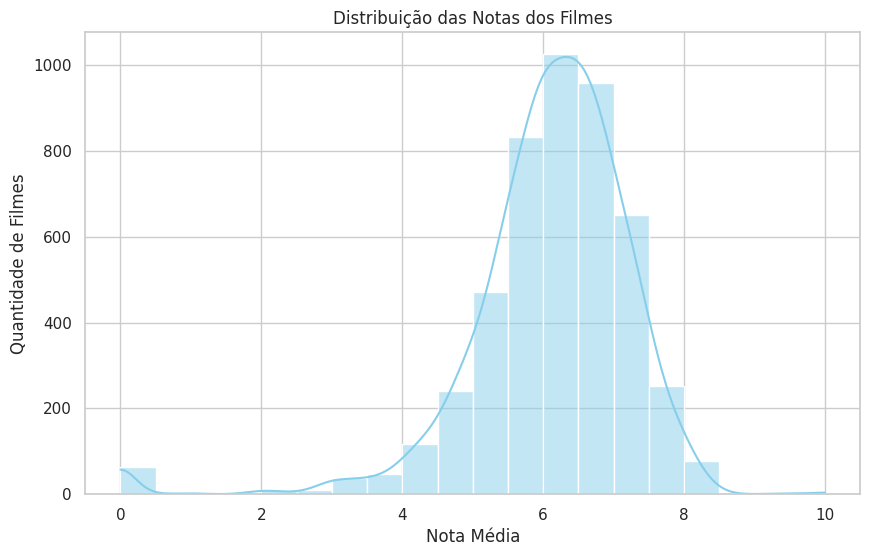

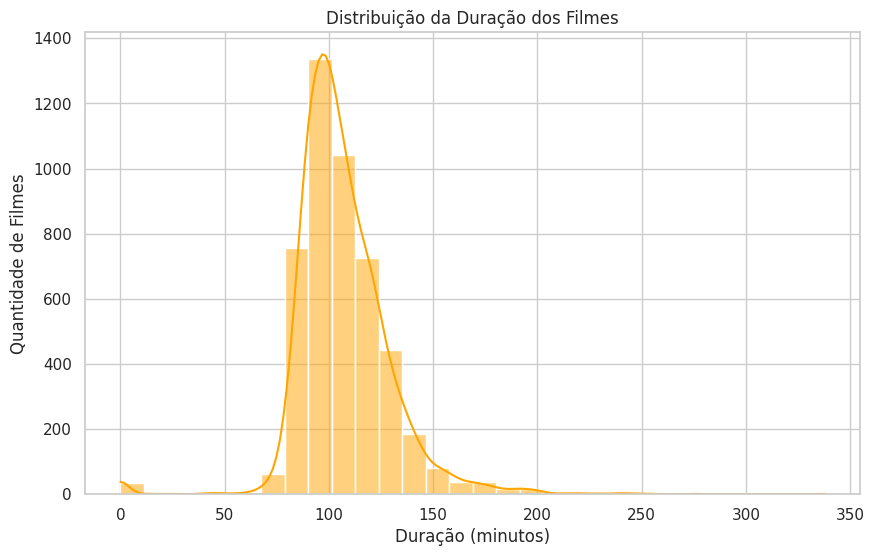

In [32]:
# Histograma: Distribuição das notas
plt.figure()
sns.histplot(df['vote_average'], bins=20, kde=True, color='skyblue')
plt.title('Distribuição das Notas dos Filmes')
plt.xlabel('Nota Média')
plt.ylabel('Quantidade de Filmes')
plt.show()

print()

# Histograma: Distribuição da Duração dos Filmes
plt.figure()
sns.histplot(df['runtime'].dropna(), bins=30, kde=True, color='orange')
plt.title('Distribuição da Duração dos Filmes')
plt.xlabel('Duração (minutos)')
plt.ylabel('Quantidade de Filmes')
plt.show()


📈 Gráficos de Dispersão

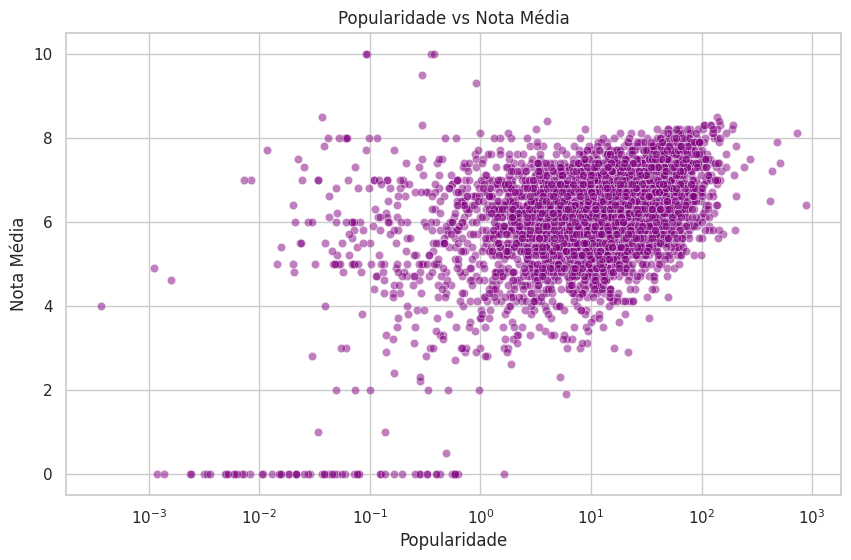

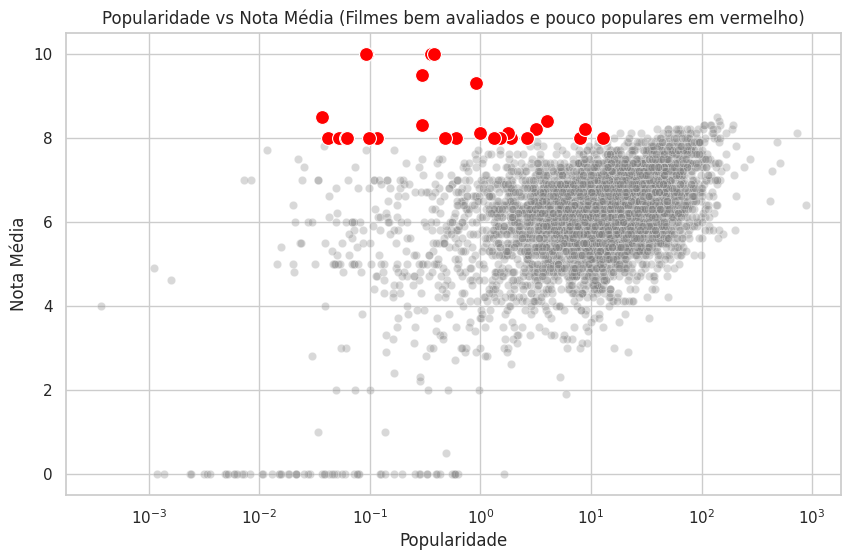

In [33]:
# Popularidade vs Nota Média
plt.figure()
sns.scatterplot(
    x='popularity',
    y='vote_average',
    data=df,
    alpha=0.5,
    color='purple'
)
plt.title('Popularidade vs Nota Média')
plt.xlabel('Popularidade')
plt.ylabel('Nota Média')
plt.xscale('log')  # escala logarítmica para popularidade (muito variada)
plt.show()

print()

# Selecionar filmes pouco populares mas bem avaliados
top_hidden = df[(df['vote_average'] >= 8) & (df['popularity'] < df['popularity'].median())]

plt.figure()
sns.scatterplot(x='popularity', y='vote_average', data=df, alpha=0.3, color='gray')
sns.scatterplot(x='popularity', y='vote_average', data=top_hidden, color='red', s=100)  # destaques em vermelho
plt.xscale('log')
plt.title('Popularidade vs Nota Média (Filmes bem avaliados e pouco populares em vermelho)')
plt.xlabel('Popularidade')
plt.ylabel('Nota Média')
plt.show()


📦 Boxplots

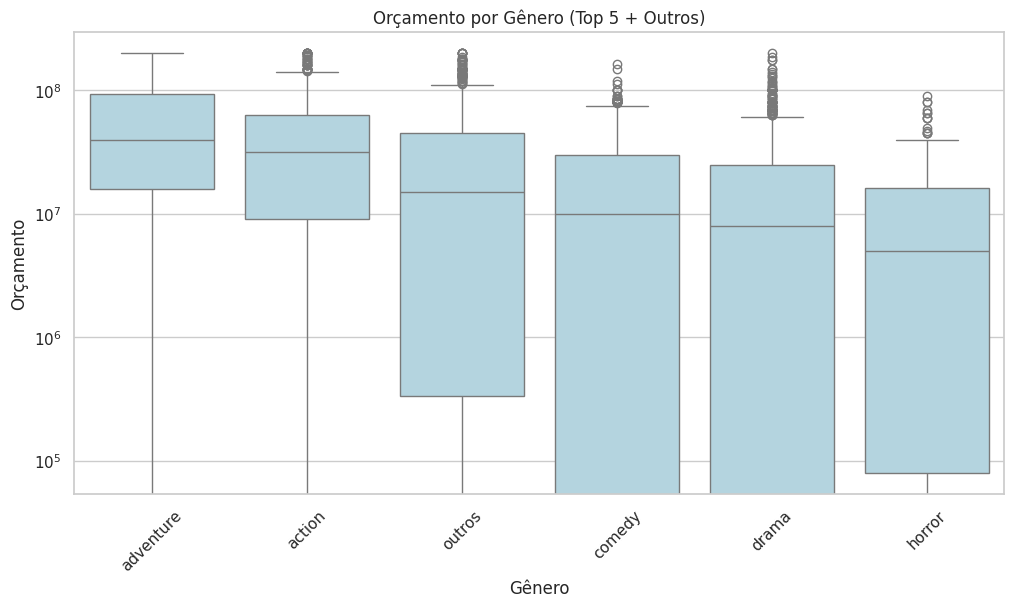

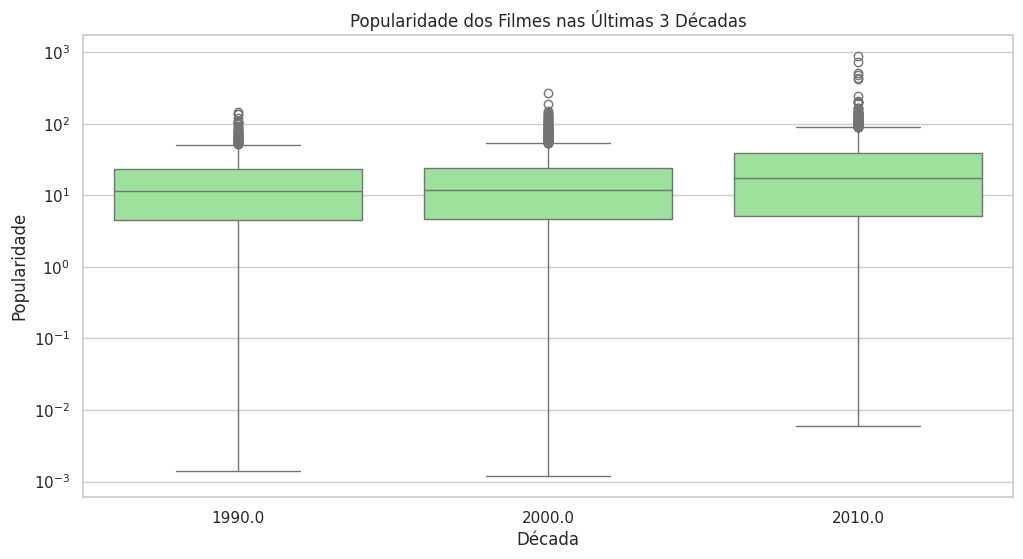

In [39]:
# Extrair o primeiro gênero de cada filme
def get_main_genre(genres_str):
    try:
        genres_list = ast.literal_eval(genres_str)  # converte string para lista de dicionários
        if len(genres_list) > 0:
            return genres_list[0]['name'].lower()  # pega o nome do primeiro gênero e coloca em minúscula
        else:
            return 'desconhecido'
    except:
        return 'desconhecido'

df['main_genre'] = df['genres'].apply(get_main_genre)

# Contar frequência dos gêneros e pegar top 5
genre_counts = df['main_genre'].value_counts()
top5_genres = genre_counts.head(5).index.tolist()

# Agrupar gêneros menos frequentes em "outros"
df['genre_grouped'] = df['main_genre'].apply(lambda x: x if x in top5_genres else 'outros')

# Filtrar orçamentos extremos (> 200 milhões)
df_filtered = df[df['budget'] <= 200_000_000]

# Ordenar gêneros por mediana do orçamento
medianas = df_filtered.groupby('genre_grouped')['budget'].median().sort_values(ascending=False)
ordered_genres = medianas.index.tolist()

# Criar boxplot
plt.figure(figsize=(12,6))
sns.boxplot(
    x='genre_grouped',
    y='budget',
    data=df_filtered,
    order=ordered_genres,
    color='lightblue'
)
plt.yscale('log')
plt.title('Orçamento por Gênero (Top 5 + Outros)')
plt.xlabel('Gênero')
plt.ylabel('Orçamento')
plt.xticks(rotation=45)
plt.show()

print()

# Criar coluna de década
df['decade'] = (df['release_date'].dt.year // 10) * 10

# Filtrar apenas as últimas 3 décadas
ultimas_decadas = sorted(df['decade'].dropna().unique())[-3:]  # pega 3 últimas décadas
df_recent = df[df['decade'].isin(ultimas_decadas)]

# Criar boxplot
plt.figure(figsize=(12,6))
sns.boxplot(
    x='decade',
    y='popularity',
    data=df_recent,
    color='lightgreen'
)
plt.yscale('log')  # escala log para popularidade
plt.title('Popularidade dos Filmes nas Últimas 3 Décadas')
plt.xlabel('Década')
plt.ylabel('Popularidade')
plt.show()



📊 Gráficos de Barras

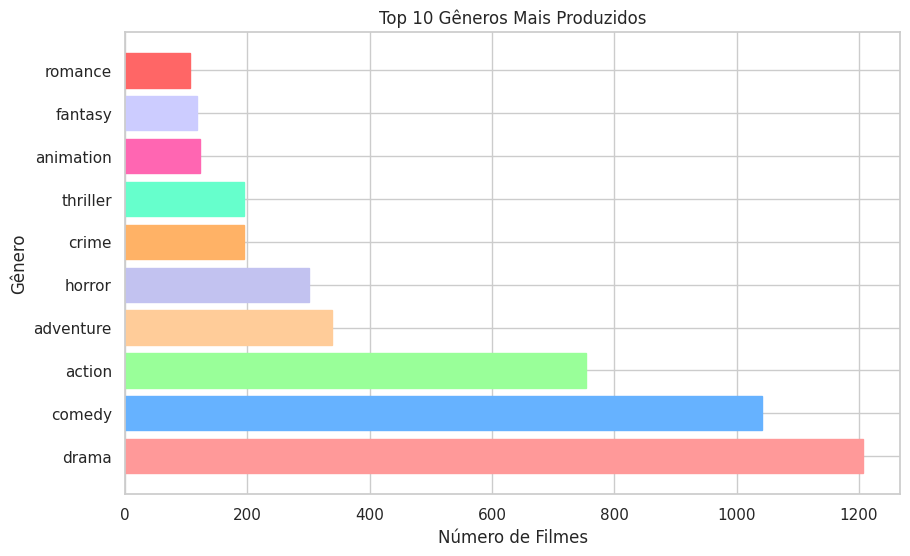

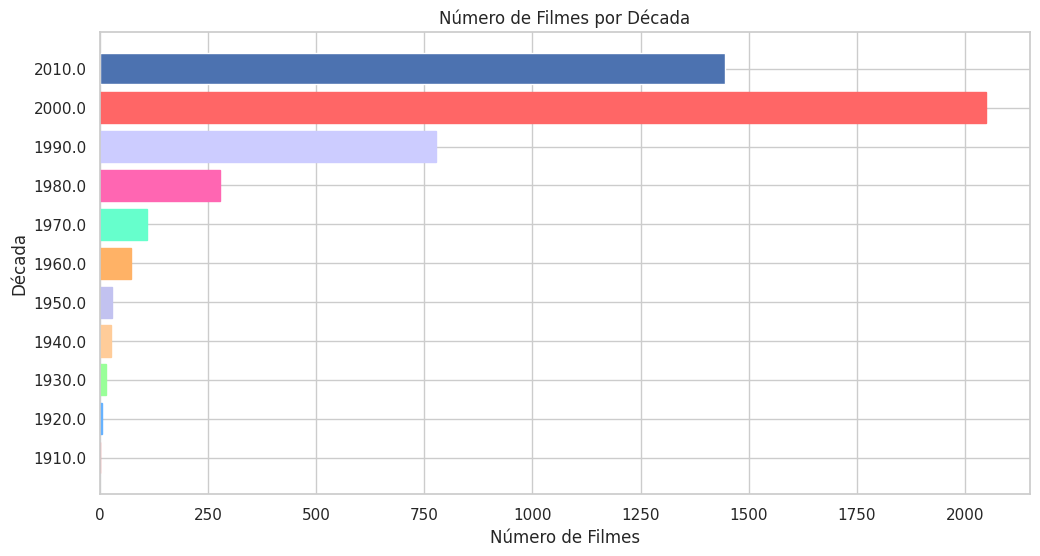

In [31]:
top_genres = df['main_genre'].value_counts().head(10)

# Contar filmes por gênero principal
plt.figure(figsize=(10,6))
bars = plt.barh(top_genres.index, top_genres.values)  # gráfico horizontal

# Aplicar cores diferentes manualmente
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#C2C2F0', '#FFB266', '#66FFCC', '#FF66B2', '#CCCCFF', '#FF6666']
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.title('Top 10 Gêneros Mais Produzidos')
plt.xlabel('Número de Filmes')
plt.ylabel('Gênero')
plt.show()

print()

# Contar filmes por década
filmes_por_decada = df['decade'].value_counts().sort_index()

# Criar gráfico horizontal
plt.figure(figsize=(12,6))
bars = plt.barh(filmes_por_decada.index.astype(str), filmes_por_decada.values)  # eixo y como string para labels

# Lista de cores para cada barra
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#C2C2F0', '#FFB266', '#66FFCC', '#FF66B2', '#CCCCFF', '#FF6666']

# Aplicar cores manualmente
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.title('Número de Filmes por Década')
plt.xlabel('Número de Filmes')
plt.ylabel('Década')
plt.show()

Modelagem Preditiva

In [35]:
# Selecionar variáveis
features = ['budget', 'revenue', 'popularity', 'vote_count']
target = 'vote_average'

# Filtrar apenas linhas sem valores ausentes
df_model = df[features + [target]].dropna()

# Separar X (features) e y (target)
X = df_model[features]
y = df_model[target]

# Opcional: normalizar ou log-transformar features grandes (budget/revenue/popularity)
import numpy as np
X['budget_log'] = np.log1p(X['budget'])
X['revenue_log'] = np.log1p(X['revenue'])
X['popularity_log'] = np.log1p(X['popularity'])

# Usar apenas as colunas transformadas para o modelo
X_model = X[['budget_log', 'revenue_log', 'popularity_log', 'vote_count']]


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, random_state=42
)


In [37]:
from sklearn.linear_model import LinearRegression

# Criar o modelo
model = LinearRegression()

# Treinar
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MSE: 1.194
RMSE: 1.093
R²: 0.208
